# Amplifier Generation Tutorial 

**By gLayout Team**

__Content creators:__ Aleta

___
# Tutorial Objectives

This notebook is a tutorial on-
* Generation of the instrumentation amplifier
* How to manually generate VDD and VSS routing for the instrumentation amplifier
* How to generate ports for VDD, VSS, VBIAS, and VCM

## Creating the Environment for Layout Generation

In [8]:
import os
import gdstk
import svgutils.transform as sg
import IPython.display
import ipywidgets as widgets
from gdsfactory import Component
from gdsfactory.port import Port
from gdsfactory.components import rectangle
from glayout import gf180
from glayout import nmos, pmos, tapring
from glayout.util.comp_utils import evaluate_bbox, prec_center, align_comp_to_port
from glayout import rename_ports_by_orientation
# ROUTING
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route

# VIAS import
from glayout import via_stack, via_array

hide = widgets.Output()

# display helpers
def display_gds(gds_file, path, scale=3):
    top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
    top_level_cell.write_svg(os.path.join(path, "out.svg"))
    fig = sg.fromfile(os.path.join(path, "out.svg"))
    fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
    fig.save(os.path.join(path, "out.svg"))
    IPython.display.display(IPython.display.SVG(os.path.join(path, "out.svg")))
def display_component(component, path, scale=3):
    with hide:
        component.write_gds(os.path.join(path, "out.gds"))
    display_gds(os.path.join(path, "out.gds"), path, scale)
    
# Dummy wrapper if component_snap_to_grid is not directly available in your version (*)
def component_snap_to_grid(component):
    return component

from instrumentation_amplifier import generate_ina, add_amplifier_labels

## Define the pmos and nmos parameter 

In [4]:
# default kwargs (gLayout parameter for 1 NMOS/PMOS)
nmos_kwargs = {
    "with_tie": True, "with_dnwell": False, "sd_route_topmet": "met2",
    "gate_route_topmet": "met2", "sd_route_left": True, "rmult": None,
    "gate_rmult": 1, "interfinger_rmult": 1, "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True
}

pmos_kwargs = {
    "with_tie": True, "dnwell": False, "sd_route_topmet": "met2",
    "gate_route_topmet": "met2", "sd_route_left": True, "rmult": None,
    "gate_rmult": 1, "interfinger_rmult": 1, "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True
}

## Define the instrumentation amplifier parameters

Configuration  : Contains the PMOS and NMOS device parameters used in the amplifier, including transistor width, length,
               finger count, multipliers, dummy devices, and metal tie layers, which define the sizing and layout
               configuration of each transistor block.
               
x_distance    : Sets the horizontal separation between the left and right sides of the differential pair.

row_gap       : Defines the vertical spacing between different transistor rows.

bias_gap      : Defines the vertical spacing between the bias block and the main circuit.

trunk_pitch_in: Controls the pitch (spacing/width) of the vertical routing trunks for the input signals.

trunk_pitch_out: Controls the pitch of the vertical routing trunks for the output signals.

outpad_margin : Sets the spacing buffer between the core amplifier layout and the I/O pads or chip boundary.

outer_keepout : Defines the clearance distance for the outer guard ring.

nmos_pair_outer_ring_padding: Sets the spacing between the NMOS differential pair and the outer guard ring.

bias_gate_route_dx: Specifies the horizontal extension used to route the VBIAS connection.

c_route_extension: Defines the extension length for the common routing path.

vcm_dx        : Sets the horizontal offset for the VCM (common-mode voltage) connection.

vin_dx        : Specifies the horizontal routing extension for the input connections.

vout_dx       : Specifies the horizontal routing extension for the output connections.

In [5]:
cfg= {
    "pmos_pair": {"pdk": gf180, "placement": "horizontal", "width": (6, 6), "length": (3, 3), "fingers": (6, 6), "multipliers": (1, 1), "dummy_1": (True, True), "dummy_2": (True, True), "tie_layers1": ("met2", "met1"), "tie_layers2": ("met2", "met1"), "sd_rmult": 1},
    "pmos_bias": {"pdk": gf180, "placement": "horizontal", "width": (0.5, 0.5), "length": (6.9, 6.9), "fingers": (1, 1), "multipliers": (1, 1), "dummy_1": (True, True), "dummy_2": (True, True), "tie_layers1": ("met2", "met1"), "tie_layers2": ("met2", "met1"), "sd_rmult": 1},
    "nmos_pair": {"pdk": gf180, "placement": "horizontal", "width": (3, 3), "length": (3, 3), "fingers": (1, 1), "multipliers": (1, 1), "dummy_1": (True, True), "dummy_2": (True, True), "tie_layers1": ("met2", "met1"), "tie_layers2": ("met2", "met1"), "sd_rmult": 1},
    "nmos_mirror": {"pdk": gf180, "placement": "horizontal", "width": (0.5, 0.5), "length": (6.9, 6.9), "fingers": (1, 1), "multipliers": (1, 1), "dummy_1": (True, True), "dummy_2": (True, True), "tie_layers1": ("met2", "met1"), "tie_layers2": ("met2", "met1"), "sd_rmult": 1},
    "pmos_diode": {"pdk": gf180, "placement": "horizontal", "width": (0.5, 0.5), "length": (6.9, 6.9), "fingers": (1, 1), "multipliers": (1, 1), "dummy_1": (True, True), "dummy_2": (True, True), "tie_layers1": ("met2", "met1"), "tie_layers2": ("met2", "met1"), "sd_rmult": 1}
    }

## Generate GDS 

In [10]:
ALL_TOP=generate_ina(    
    pdk=gf180,
    CFG=cfg, # pdk
    x_distance=5, # Sets the horizontal separation between the left and right sides of the differential pairs.
    row_gap=6.0, # Defines the vertical spacing between the different transistor rows
    bias_gap=4.0, # Defines the vertical spacing between the bias block.
    trunk_pitch_in=3.4, # Controls the width/pitch of the vertical signal trunks for input.
    trunk_pitch_out=1.0, # Controls the width/pitch of the vertical signal trunks for output.
    outpad_margin=35.0, # Define the spacing buffer between the core amplifier circuit and the external I/O pads (or the chip boundary).
    outer_keepout=6.0, # Sets the clearance distance for the outermost guard ring.
    nmos_pair_outer_ring_padding=2.2, # outer ring padring spacing for NMOS pair
    bias_gate_route_dx=25.0, # Specifies the horizontal extension length for the VBIAS via
    c_route_extension=6.0, # Set the c_route length and structure.
    vcm_dx=-20.0, # Sets the offset location for the Common Mode Voltage (VCM) connection (the via)
    vin_dx=40.0, # Specifies the horizontal extension length for the input (the via)
    vout_dx=40.0, # Specifies the horizontal extension length for the output (the via)
    nmos_kwargs=nmos_kwargs,
    pmos_kwargs=pmos_kwargs
    )
ALL_TOP = add_amplifier_labels(ALL_TOP, gf180)
ALL_TOP.name = "INA_PARAMETERIZED"
ALL_TOP.write_gds("INA_PARAMETERIZED.gds")

2026-05-01 14:48:36.935 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.

2026-05-01 14:48:37.939 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/generic_tech/layer_views.yaml'.
2026-05-01 14:48:37.941 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active
2026-05-01 14:48:37.983 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active
2026-05-01 14:49:07.533 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'INA_PARAMETERIZED.gds'


PosixPath('INA_PARAMETERIZED.gds')

## Get access to bias_ref and vcm

In [13]:
viaarray = via_array(gf180, "met2", "met3", (2,1))
bias_ref = ALL_TOP.info["stages"]["bias_ref"]
via_pmos_src_L = ALL_TOP.info["stages"]["via_tail"]

## Route VDD and VSS

In [15]:
pdk=gf180
# VDD LEFT SIDE WAY
VDD1_a_via = ALL_TOP << viaarray
VDD1_a_via.move(bias_ref.ports["tie_N_array_row0_col0_top_met_E"].center)
VDD2_via = ALL_TOP << viaarray
VDD2_via.move(bias_ref.ports["tie_S_array_row0_col0_top_met_E"].center)


# VIA ARRAY TO SOURCE BIAS REF
bias_src_port_1 = bias_ref.ports["multiplier_0_drain_W"]
via_ref_vdd_bias = VDD1_a_via.center
VDD1_b_via = ALL_TOP << viaarray
VDD1_b_via.move((via_ref_vdd_bias[0], bias_src_port_1.center[1]))
#ALL_TOP << straight_route(pdk,VDD1_b_via.ports["array_row0_col0_bottom_layer_W"], bias_src_port_1, width = 0.8)
VDD1_c_via = ALL_TOP << viaarray
VDD1_c_via.move((12, bias_src_port_1.center[1]))
ALL_TOP << straight_route(pdk,VDD1_b_via.ports["array_row0_col0_bottom_layer_W"], VDD1_c_via.ports["array_row0_col0_bottom_layer_E"])

# VDD RIGHT SIDE WAY **
VDD5_via = ALL_TOP << viaarray
VDD6_via = ALL_TOP << viaarray
VDD5_via.movex(VDD1_c_via.center[0]).movey(2.3)
VDD6_via.movex(VDD1_c_via.center[0]).movey(-2.3)

# ---- ROUTE VDD
route_vertical_VDD_L = straight_route(pdk,VDD1_a_via.ports["top_met_N"],VDD2_via.ports["top_met_S"], width = 2)
ALL_TOP << route_vertical_VDD_L
route_vertical_VDD_R = straight_route(pdk,VDD5_via.ports["top_met_N"],VDD6_via.ports["top_met_S"], width = 2)
ALL_TOP << route_vertical_VDD_R

# VSS LEFT SIDE WAY
VSS1_via = ALL_TOP << viaarray
VSS1_via.movex(VDD1_a_via.center[0]).movey(9.3)
VSS1_via.movex(6)
VSS2_via = ALL_TOP << viaarray
VSS3_via = ALL_TOP << viaarray
VSS4_via = ALL_TOP << viaarray
VSS2_via.movex(VSS1_via.center[0]).movey(-7)
VSS3_via.movex(VSS1_via.center[0]).movey(-26)
VSS4_via.movex(VSS1_via.center[0]).movey(-45.2)
VSS5_via = ALL_TOP << viaarray
VSS6_via = ALL_TOP << viaarray
VSS7_via = ALL_TOP << viaarray
VSS5_via.movex(VSS1_via.center[0]).movey(-46.5)
VSS6_via.movex(VSS1_via.center[0]).movey(-58.7)
VSS7_via.movex(VSS1_via.center[0]).movey(-72.6)

# ---- ROUTE VSS LEFT
route_vertical_VSS_L = straight_route(pdk,VSS1_via.ports["top_met_N"],VSS7_via.ports["top_met_S"], width = 2)
ALL_TOP << route_vertical_VSS_L

# VSS RIGHT SIDE WAY
VSS8_via = ALL_TOP << viaarray
VSS9_via = ALL_TOP << viaarray
VSS10_via = ALL_TOP << viaarray
VSS11_via = ALL_TOP << viaarray
VSS12_via = ALL_TOP << viaarray
VSS13_via = ALL_TOP << viaarray
VSS14_via = ALL_TOP << viaarray
VSS8_via.movex(VDD1_a_via.center[0]).movey(9.3)
VSS8_via.movex(18)
VSS9_via.movex(VSS8_via.center[0]).movey(-7)
VSS10_via.movex(VSS8_via.center[0]).movey(-26)
VSS11_via.movex(VSS8_via.center[0]).movey(-45.2)
VSS12_via.movex(VSS8_via.center[0]).movey(-46.5)
VSS13_via.movex(VSS8_via.center[0]).movey(-58.7)
VSS14_via.movex(VSS8_via.center[0]).movey(-72.6)

# ---- ROUTE VSS RIGHT
route_vertical_VSS_R = straight_route(pdk,VSS8_via.ports["top_met_N"],VSS14_via.ports["top_met_S"], width = 2)
ALL_TOP << route_vertical_VSS_R

ComponentReference (parent Component "straight_route_8f00c1a5", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

## Add ports & label for VDD, VBIAS, VCM, and VSS

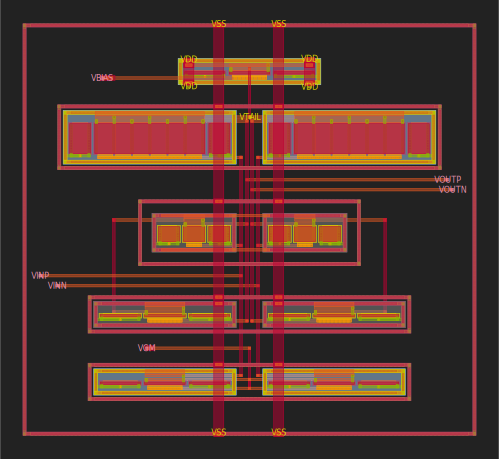

In [16]:
ALL_TOP.add_ports(VDD1_a_via.get_ports_list(), prefix="VDD_TOPL_")
ALL_TOP.add_ports(VDD5_via.get_ports_list(), prefix="VDD_TOPR_")
ALL_TOP.add_ports(VDD2_via.get_ports_list(), prefix="VDD_BOTTOML_")
ALL_TOP.add_ports(VDD6_via.get_ports_list(), prefix="VDD_BOTTOMR_")

ALL_TOP.add_ports(VSS1_via.get_ports_list(), prefix="VSS_TOPL_")
ALL_TOP.add_ports(VSS7_via.get_ports_list(), prefix="VSS_BOTTOML_")
ALL_TOP.add_ports(VSS8_via.get_ports_list(), prefix="VSS_TOPR_")
ALL_TOP.add_ports(VSS14_via.get_ports_list(), prefix="VSS_BOTTOMR_")

ALL_TOP.add_ports(via_pmos_src_L.get_ports_list(), prefix="VTAIL_")

component = component_snap_to_grid(rename_ports_by_orientation(ALL_TOP))
##########################################################################################################
# LABELLING
##########################################################################################################
# VSS 
psize=(0.5,0.5)
move_info = list()
vsslabel = rectangle(layer=pdk.get_glayer("met3_pin"),size=psize,centered=True).copy()
vsslabel.add_label(text="VSS",layer=pdk.get_glayer("met3_label"))
move_info.append((vsslabel,component.ports["VSS_TOPL_top_met_N"],None))
move_info.append((vsslabel,component.ports["VSS_BOTTOML_top_met_N"],None))
move_info.append((vsslabel,component.ports["VSS_TOPR_top_met_N"],None))
move_info.append((vsslabel,component.ports["VSS_BOTTOMR_top_met_N"],None))
#vss_ref= ALL_TOP << vsslabel

#VDD
vddlabel = rectangle(layer=pdk.get_glayer("met3_pin"),size=psize,centered=True).copy()
vddlabel.add_label(text="VDD",layer=pdk.get_glayer("met3_pin"))
move_info.append((vddlabel,component.ports["VDD_TOPL_top_met_N"],None))
move_info.append((vddlabel,component.ports["VDD_TOPR_top_met_N"],None))
move_info.append((vddlabel,component.ports["VDD_BOTTOML_top_met_S"],None))
move_info.append((vddlabel,component.ports["VDD_BOTTOMR_top_met_S"],None))
#vdd_ref = ALL_TOP << vddlabel

# Vbias label
vbiaslabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
vbiaslabel.add_label(text="VBIAS",layer=pdk.get_glayer("met2_pin"))
vbiaslabel_ref = align_comp_to_port(vbiaslabel, component.ports["VBIAS_top_met_W"], alignment=('c','c'))
vbiaslabel_ref.movex(0.4)
ALL_TOP.add(vbiaslabel_ref)
#vbias_ref = ALL_TOP << vbiaslabel

# v_node label
vtaillabel= rectangle(layer=pdk.get_glayer("met3_pin"),size=psize,centered=True).copy()
vtaillabel.add_label(text="VTAIL",layer=pdk.get_glayer("met3_pin"))
vtaillabel_ref = align_comp_to_port(vtaillabel, component.ports["VTAIL_top_met_W"], alignment=('c','c'))
vtaillabel_ref.movex(0.4)
ALL_TOP.add(vtaillabel_ref)

# VCM label
vcmlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
vcmlabel.add_label(text="VCM",layer=pdk.get_glayer("met2_pin"))
vcmlabel_ref = align_comp_to_port(vcmlabel, component.ports["VCM_top_met_W"], alignment=('c','c'))
vcmlabel_ref.movex(0.4)
ALL_TOP.add(vcmlabel_ref)
#vcm_ref = ALL_TOP << vcmlabel
for comp, prt, alignment in move_info:
        alignment = ('c','b') if alignment is None else alignment
        compref = align_comp_to_port(comp, prt, alignment=alignment)
        ALL_TOP.add(compref)
component = ALL_TOP.flatten()

display_component(component, scale =0.5,path="")

## Notes

You may modify the instrumentation amplifier specifications according to your design requirements. The VDD and VSS routing are not generated automatically and should be created manually by following the routing and access methods demonstrated in this tutorial. Other parameters, such as device sizing and gain configuration, may also be adjusted as needed.